--- ARIMAX(7,1,1) Evaluation ---
RMSE: 530.13
MAE: 441.44


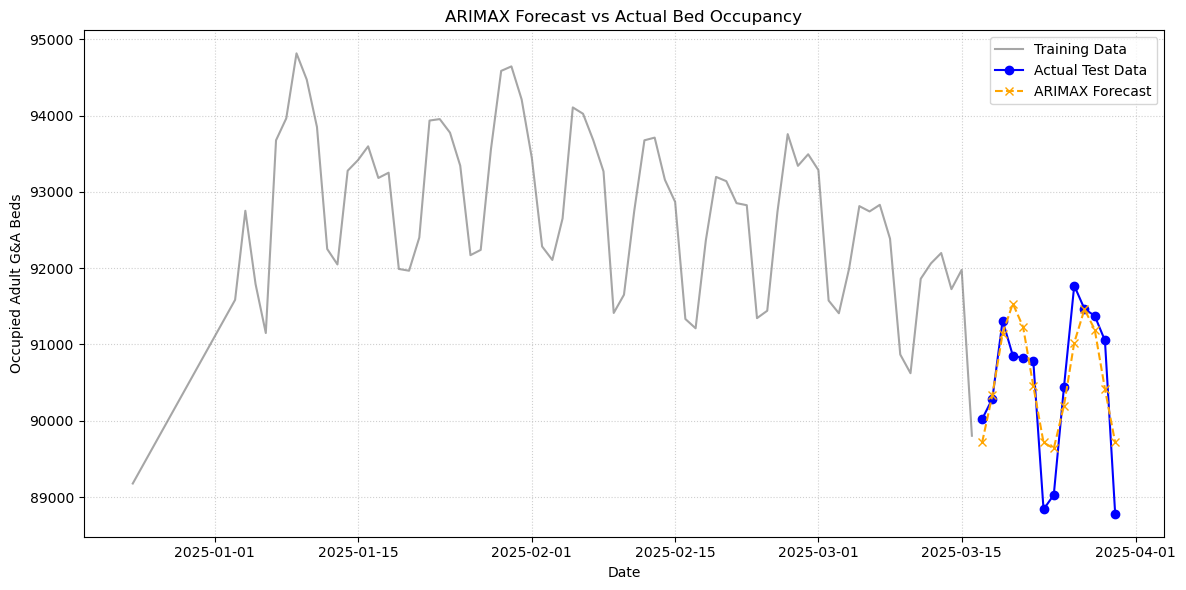


--- Residual Diagnostics ---


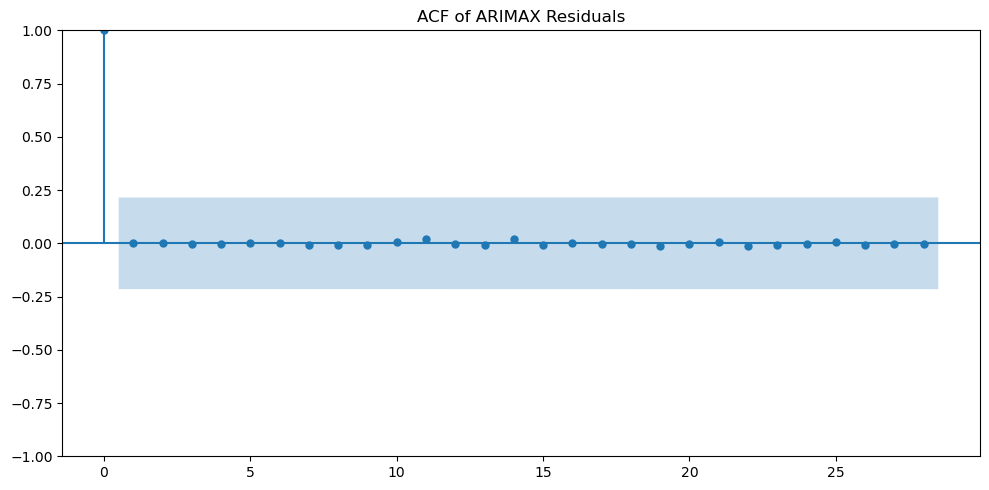

Ljung-Box Test Results (Null Hypothesis: Residuals are independent white noise):
     lb_stat  lb_pvalue
7   0.008416        1.0
14  0.109638        1.0


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Step 1: Data Loading & Preprocessing
# ==========================================
file_name = 'nhs_uec_adult_ga_beds_england_timeseries.csv'
df = pd.read_csv(file_name)
date_col, bed_col = df.columns[0], df.columns[1]
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df = df.sort_index()
beds_series = df[bed_col].astype(float)

# Handle holiday regime shifts via linear interpolation
holiday_mask = (beds_series.index >= '2024-12-24') & (beds_series.index <= '2025-01-02')
beds_cleaned = beds_series.copy()
beds_cleaned.loc[holiday_mask] = np.nan
beds_cleaned = beds_cleaned.interpolate(method='linear')

# ==========================================
# Step 2: Unified Feature Engineering (Master DataFrame)
# ==========================================
df_master = pd.DataFrame({'Beds': beds_cleaned})

# 2.1 Cyclic topology encoding (Shared across models)
d_series = (df_master.index - df_master.index.min()).days
df_master['sin_day'] = np.sin(2 * np.pi * d_series / 7)
df_master['cos_day'] = np.cos(2 * np.pi * d_series / 7)

# 2.2 Autoregressive & rolling features (For downstream ML models)
df_master['lag_1'] = df_master['Beds'].shift(1)
df_master['lag_7'] = df_master['Beds'].shift(7)
df_master['lag_28'] = df_master['Beds'].shift(28)
df_master['rolling_mean_7'] = df_master['Beds'].shift(1).rolling(window=7).mean()
df_master['rolling_std_7'] = df_master['Beds'].shift(1).rolling(window=7).std()

# Drop NaNs to ensure temporal alignment
df_master.dropna(inplace=True)

# ==========================================
# Step 3: Train/Test Split (Time-aware)
# ==========================================
K = 14
train_df = df_master.iloc[:-K]
test_df = df_master.iloc[-K:]

# Target variable
y_train = train_df['Beds']
y_test = test_df['Beds']

# Exogenous variables specifically for ARIMAX
exog_cols = ['sin_day', 'cos_day']
train_exog_arima = train_df[exog_cols]
test_exog_arima = test_df[exog_cols]

# ==========================================
# Step 4: ARIMAX(7,1,1) Model Training
# ==========================================
model = ARIMA(endog=y_train, exog=train_exog_arima, order=(7, 1, 1))
model_fit = model.fit()

# ==========================================
# Step 5: Forecasting & Evaluation
# ==========================================
predictions = model_fit.forecast(steps=K, exog=test_exog_arima)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
print("--- ARIMAX(7,1,1) Evaluation ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# ==========================================
# Step 6: Visualization
# ==========================================
plt.figure(figsize=(12, 6))

# Safely select up to the last 90 days of training data for visual clarity
train_plot_data = train_df.tail(90)
plt.plot(train_plot_data.index, train_plot_data['Beds'], label='Training Data', color='gray', alpha=0.7)
plt.plot(y_test.index, y_test, label='Actual Test Data', color='blue', marker='o')
plt.plot(y_test.index, predictions, label='ARIMAX Forecast', color='orange', linestyle='--', marker='x')
plt.title('ARIMAX Forecast vs Actual Bed Occupancy')
plt.xlabel('Date')
plt.ylabel('Occupied Adult G&A Beds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('RealData_ARIMA_Forecast.png', dpi=300)
plt.show()

# ==========================================
# Step 7: Residual Diagnostics (Ljung-Box Test)
# ==========================================
print("\n--- Residual Diagnostics ---")
residuals = model_fit.resid

# Plot Autocorrelation Function (ACF) of residuals
fig, ax = plt.subplots(figsize=(10, 5))
sm.graphics.tsa.plot_acf(residuals, lags=28, ax=ax, title="ACF of ARIMAX Residuals")
plt.tight_layout()
plt.savefig('Residual_ACF.png', dpi=300)
plt.show()

# Ljung-Box test to evaluate if residuals resemble white noise
# Focusing on seasonal lags 7 and 14
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[7, 14], return_df=True)
print("Ljung-Box Test Results (Null Hypothesis: Residuals are independent white noise):")
print(lb_test)


In [17]:
!pip install lightgbm

--- Training LightGBM Model ---
Model training completed.

--- LightGBM Point Forecast Evaluation ---
RMSE: 930.80
MAE: 731.44


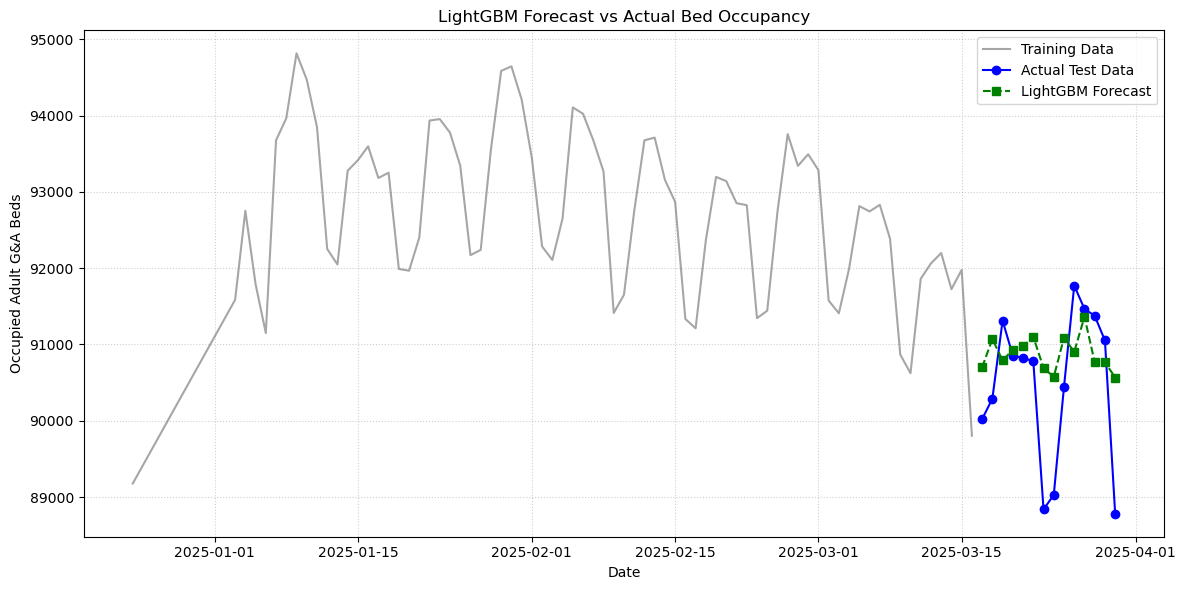

In [6]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# Step 1: Model Training (LightGBM Point Forecast)
# ==========================================
print("--- Training LightGBM Model ---")

# Extract machine learning features from the unified Master DataFrame
ml_features = ['lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'sin_day', 'cos_day']
X_train_ml = train_df[ml_features]
X_test_ml = test_df[ml_features]

# Define model hyperparameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# Construct the LightGBM dataset
lgb_train = lgb.Dataset(X_train_ml, y_train)

# Train the gradient boosting model
gbm = lgb.train(params, lgb_train, num_boost_round=100)
print("Model training completed.")

# ==========================================
# Step 2: Forecasting & Error Evaluation
# ==========================================
lgb_predictions = gbm.predict(X_test_ml)

rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_predictions))
mae_lgb = mean_absolute_error(y_test, lgb_predictions)

print("\n--- LightGBM Point Forecast Evaluation ---")
print(f"RMSE: {rmse_lgb:.2f}")
print(f"MAE: {mae_lgb:.2f}")

# ==========================================
# Step 3: Visualization
# ==========================================
plt.figure(figsize=(12, 6))

# Safely select up to the last 90 days of training data for visual clarity
train_plot_data = train_df.tail(90)

plt.plot(train_plot_data.index, train_plot_data['Beds'], label='Training Data', color='gray', alpha=0.7)
plt.plot(y_test.index, y_test, label='Actual Test Data', color='blue', marker='o')
plt.plot(y_test.index, lgb_predictions, label='LightGBM Forecast', color='green', linestyle='--', marker='s')

plt.title("LightGBM Forecast vs Actual Bed Occupancy")
plt.xlabel("Date")
plt.ylabel("Occupied Adult G&A Beds")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('LightGBM_Forecast.png', dpi=300)
plt.show()

--- Training LightGBM Quantile Regression Models ---
Training model for quantile: 0.1
Training model for quantile: 0.5
Training model for quantile: 0.9
Quantile models training completed.


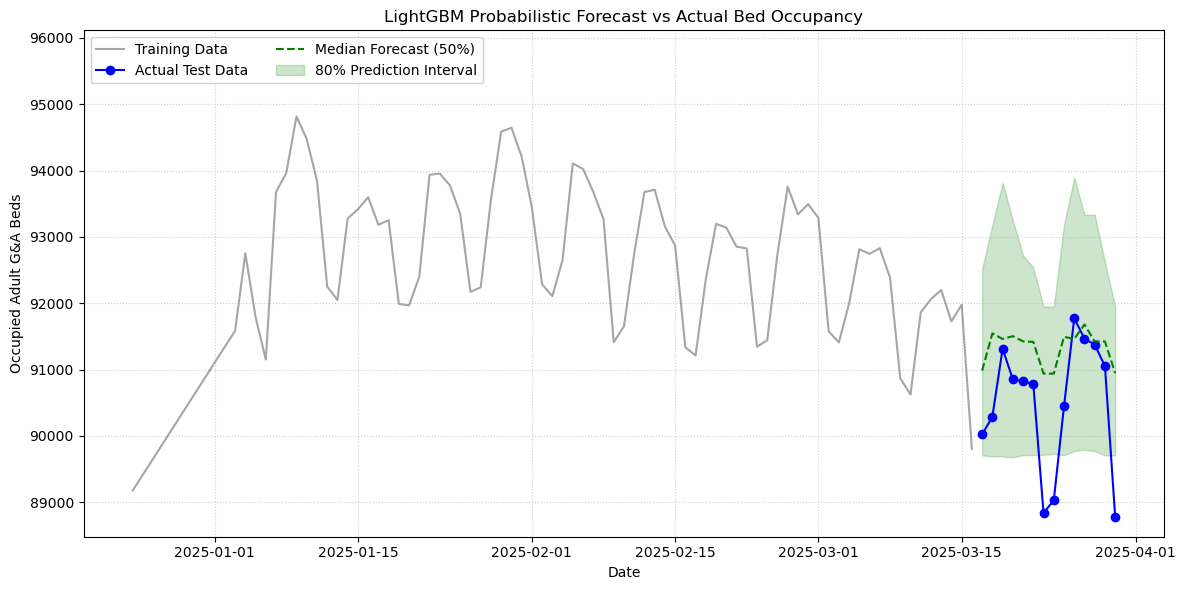

In [7]:
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np

# ==========================================
# Step 1: Model Training (LightGBM Quantile Regression)
# ==========================================
print("--- Training LightGBM Quantile Regression Models ---")

# We target the 10th, 50th, and 90th percentiles to construct an 80% prediction interval
quantiles = [0.1, 0.5, 0.9]
quantile_predictions = {}

# Construct the LightGBM dataset using the unified features
lgb_train_q = lgb.Dataset(X_train_ml, y_train)

for alpha in quantiles:
    print(f"Training model for quantile: {alpha}")
    params_quantile = {
        'objective': 'quantile',
        'alpha': alpha,
        'metric': 'quantile',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbose': -1
    }
    
    # Train the gradient boosting model for the specific quantile
    gbm_q = lgb.train(params_quantile, lgb_train_q, num_boost_round=100)
    
    # Store the predictions
    quantile_predictions[alpha] = gbm_q.predict(X_test_ml)

print("Quantile models training completed.")

# ==========================================
# Step 2: Visualization (Probabilistic Forecast)
# ==========================================
plt.figure(figsize=(12, 6))

# Safely select up to the last 90 days of training data for visual clarity
train_plot_data = train_df.tail(90)

# 1. Plot historical training data
plt.plot(train_plot_data.index, train_plot_data['Beds'], label='Training Data', color='gray', alpha=0.7)

# 2. Plot actual test data
plt.plot(y_test.index, y_test, label='Actual Test Data', color='blue', marker='o')

# 3. Plot the median forecast (50th percentile)
plt.plot(y_test.index, quantile_predictions[0.5], label='Median Forecast (50%)', color='green', linestyle='--')

# 4. Fill the 80% Prediction Interval (10th to 90th percentiles)
plt.fill_between(y_test.index, 
                 quantile_predictions[0.1], 
                 quantile_predictions[0.9], 
                 color='green', alpha=0.2, 
                 label='80% Prediction Interval')

plt.title("LightGBM Probabilistic Forecast vs Actual Bed Occupancy")
plt.xlabel("Date")
plt.ylabel("Occupied Adult G&A Beds")

# Refined formatting: dynamically adjust y-axis to prevent legend overlap
y_min, y_max = plt.ylim()
plt.ylim(y_min, y_max + (y_max - y_min) * 0.15) 

plt.legend(loc='upper left', ncol=2, fontsize=10, framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('LightGBM_Quantile_Forecast.png', dpi=300)
plt.show()

--- Generating STL Decomposition ---


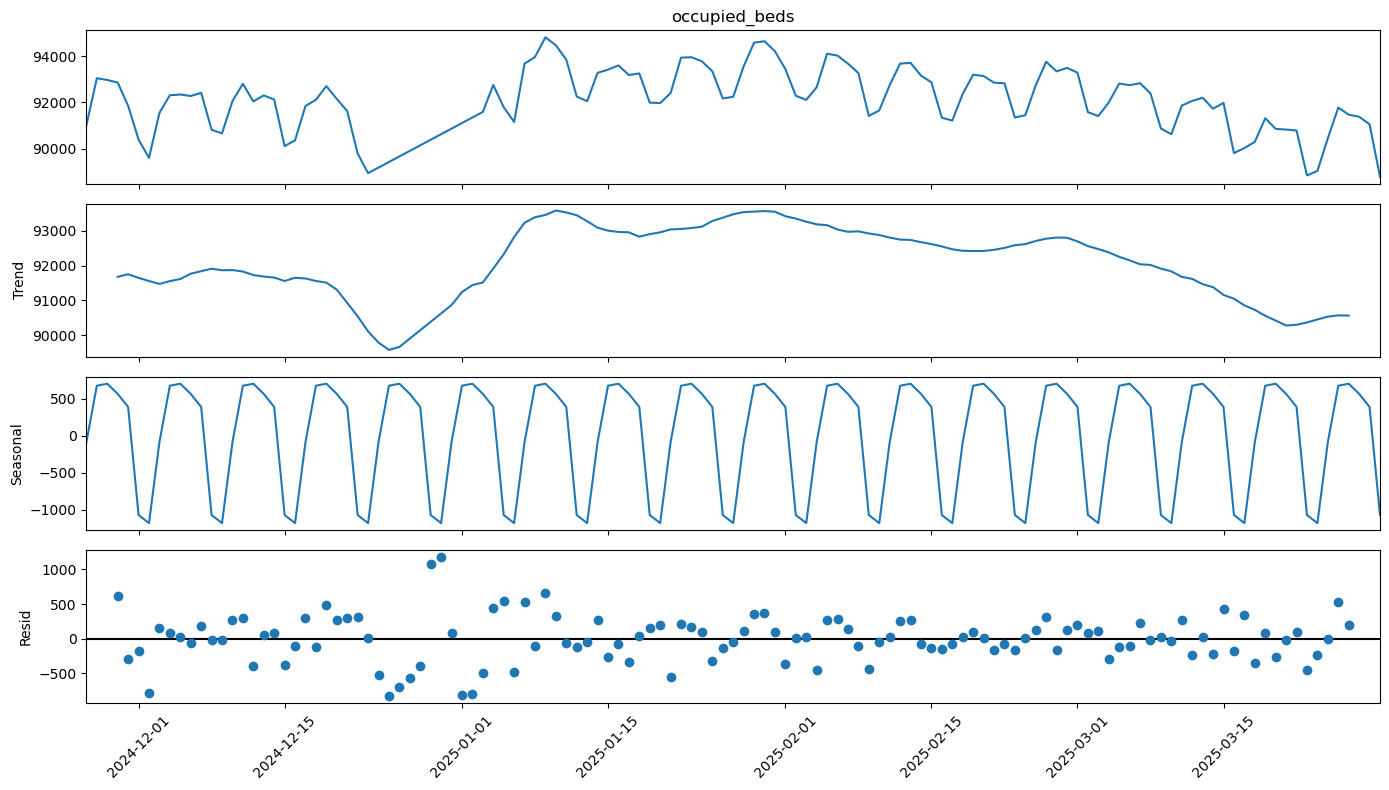

STL Decomposition plot saved successfully.

--- Generating ACF and PACF Plots ---


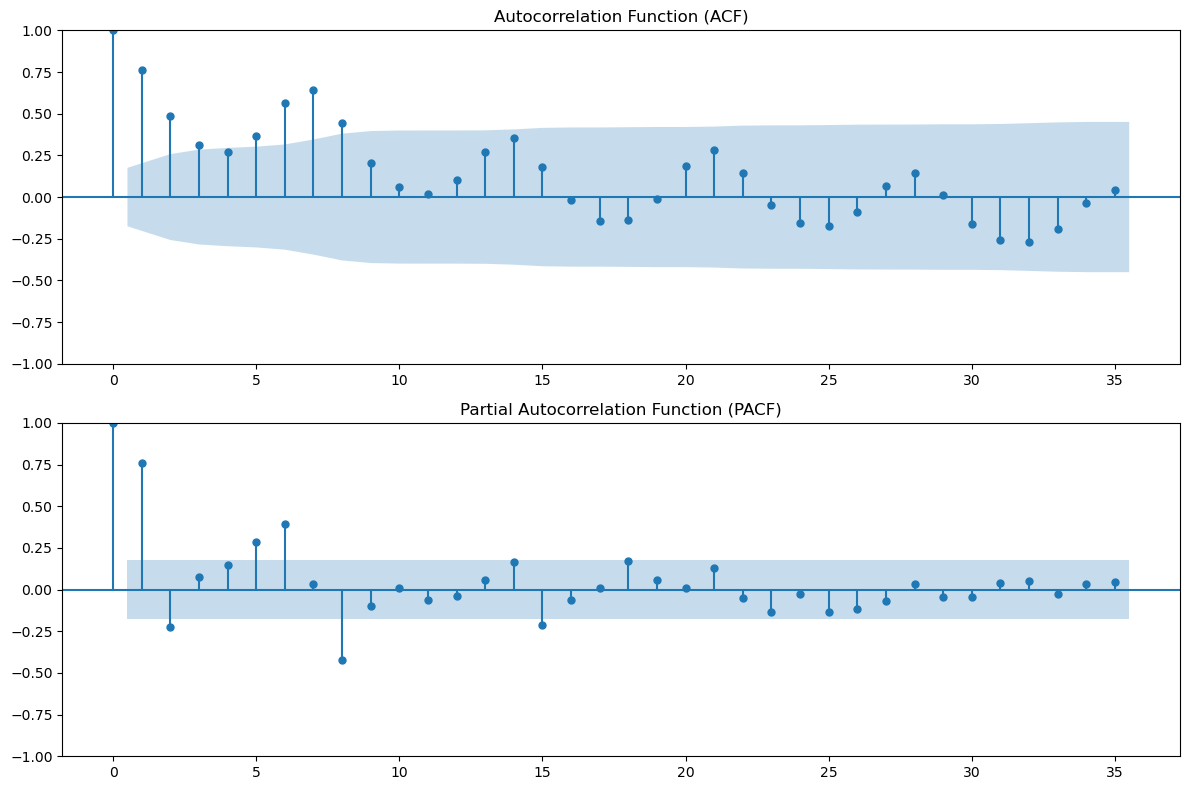

ACF and PACF plots saved successfully.


In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================
# Exploratory Data Analysis (EDA) & Statistical Diagnostics
# Note: Execute this after Step 1 using the 'beds_cleaned' series
# ==========================================
print("--- Generating STL Decomposition ---")

# Perform Seasonal-Trend decomposition
# period=7 explicitly models the weekly cyclicality in NHS operations
stl_result = seasonal_decompose(beds_cleaned, model='additive', period=7)

# Plot STL Decomposition with refined formatting
fig = stl_result.plot()
fig.set_size_inches(14, 8)

# Rotate x-axis labels by 45 degrees across all subplots to prevent overlapping
for ax in fig.axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('STL_Decomposition.png', dpi=300)
plt.show()
print("STL Decomposition plot saved successfully.")

# ==========================================
# Autocorrelation Diagnostics
# ==========================================
print("\n--- Generating ACF and PACF Plots ---")
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot Autocorrelation Function (ACF) to reveal periodic structure
plot_acf(beds_cleaned, lags=35, ax=axes[0], title='Autocorrelation Function (ACF)')

# Plot Partial Autocorrelation Function (PACF) to assist in identifying AR order
plot_pacf(beds_cleaned, lags=35, ax=axes[1], title='Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.savefig('ACF_PACF_Plot.png', dpi=300)
plt.show()
print("ACF and PACF plots saved successfully.")

In [19]:
!pip install ngboost
!pip install properscoring

--- Training NGBoost Model ---
NGBoost model training completed.

--- NGBoost Evaluation Metrics ---
RMSE: 1047.28
MAE:  850.14
CRPS: 694.49


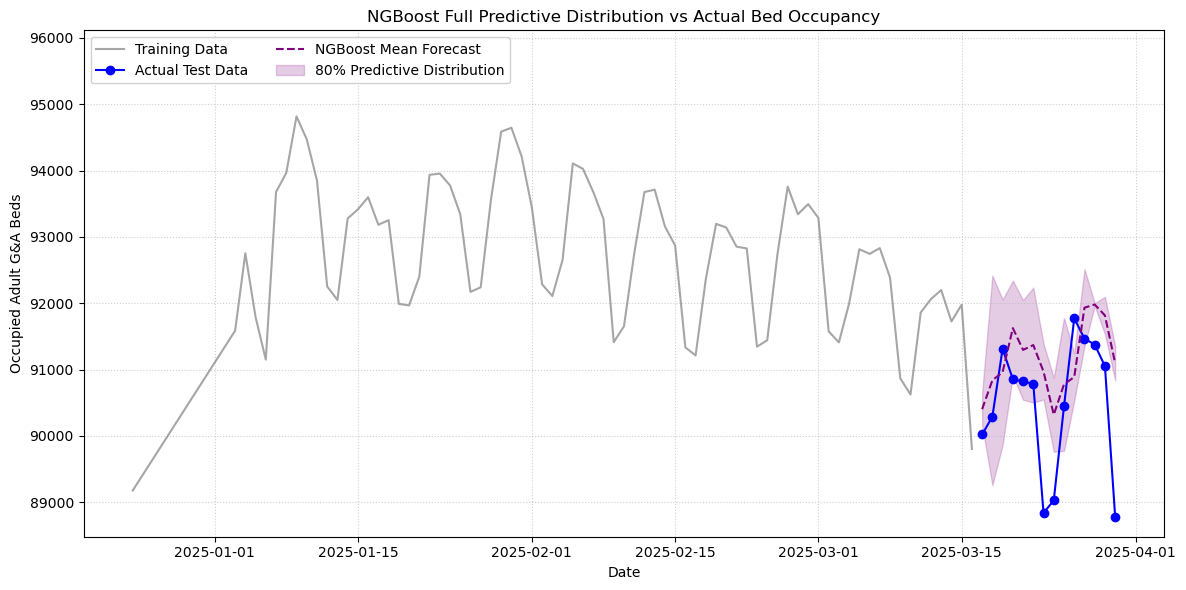

In [20]:
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import CRPScore
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# Step 1: Model Training (NGBoost Full Predictive Distribution)
# ==========================================
print("--- Training NGBoost Model ---")

# Initialize NGBoost optimizing the Continuous Ranked Probability Score (CRPS)
ngb = NGBRegressor(Dist=Normal, Score=CRPScore, n_estimators=100, learning_rate=0.05, verbose=False)

# Train using the unified machine learning features
ngb.fit(X_train_ml, y_train)
print("NGBoost model training completed.")

# ==========================================
# Step 2: Probabilistic Forecasting & Evaluation
# ==========================================
# Predict the full distribution parameters (Normal distribution: mean and scale/std)
y_preds_dist = ngb.pred_dist(X_test_ml)

# Extract predicted mean and standard deviation
y_pred_mean = ngb.predict(X_test_ml)
y_pred_std = y_preds_dist.params['scale']

# Evaluate deterministic metrics (RMSE, MAE)
rmse_ngb = np.sqrt(mean_squared_error(y_test, y_pred_mean))
mae_ngb = mean_absolute_error(y_test, y_pred_mean)

# Evaluate probabilistic calibration (CRPS)
from properscoring import crps_gaussian
crps_values = crps_gaussian(y_test, mu=y_pred_mean, sig=y_pred_std)
mean_crps = crps_values.mean()

print("\n--- NGBoost Evaluation Metrics ---")
print(f"RMSE: {rmse_ngb:.2f}")
print(f"MAE:  {mae_ngb:.2f}")
print(f"CRPS: {mean_crps:.2f}")

# ==========================================
# Step 3: Visualization (Full Predictive Distribution)
# ==========================================
plt.figure(figsize=(12, 6))

# Safely select up to the last 90 days of training data for visual clarity
train_plot_data = train_df.tail(90)

# Plot historical and actual test data
plt.plot(train_plot_data.index, train_plot_data['Beds'], label='Training Data', color='gray', alpha=0.7)
plt.plot(y_test.index, y_test, label='Actual Test Data', color='blue', marker='o')

# Plot the NGBoost predicted mean
plt.plot(y_test.index, y_pred_mean, label='NGBoost Mean Forecast', color='purple', linestyle='--')

# Calculate and shade the 80% central probability mass (mean +/- 1.28 * std for Normal distribution)
lower_bound = y_pred_mean - 1.28 * y_pred_std
upper_bound = y_pred_mean + 1.28 * y_pred_std
plt.fill_between(y_test.index, lower_bound, upper_bound, color='purple', alpha=0.2, label='80% Predictive Distribution')

plt.title("NGBoost Full Predictive Distribution vs Actual Bed Occupancy")
plt.xlabel("Date")
plt.ylabel("Occupied Adult G&A Beds")

# Refined formatting: dynamically adjust y-axis to prevent legend overlap
y_min, y_max = plt.ylim()
plt.ylim(y_min, y_max + (y_max - y_min) * 0.15) 
plt.legend(loc='upper left', ncol=2, fontsize=10, framealpha=0.9)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('NGBoost_Forecast.png', dpi=300)
plt.show()

In [12]:
!pip install shap

--- Computing SHAP Values for Model Interpretability ---


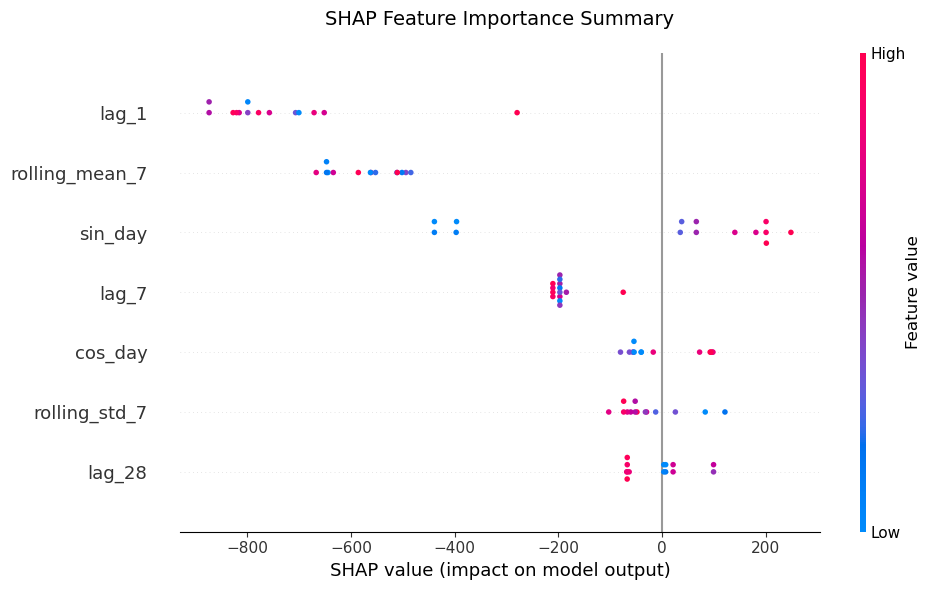

SHAP Summary Plot saved successfully.


In [13]:
import shap
import matplotlib.pyplot as plt

# ==========================================
# Step 1: Initialize SHAP Explainer & Compute Values
# Note: This block relies on the previously trained LightGBM model ('gbm')
# and the unified feature set ('X_test_ml').
# ==========================================
print("--- Computing SHAP Values for Model Interpretability ---")

# Initialize TreeExplainer (Game theoretic approach to feature attribution)
explainer = shap.TreeExplainer(gbm)

# Compute SHAP values on the test set to determine marginal feature contributions
# Updated to use 'X_test_ml' for consistency with Master DataFrame
shap_values = explainer.shap_values(X_test_ml)

# ==========================================
# Step 2: Generate SHAP Summary Plot (Global Importance)
# ==========================================
# show=False is crucial to allow further Matplotlib refinements and saving
shap.summary_plot(shap_values, X_test_ml, show=False, max_display=10, plot_size=(10, 6))

# Refine title parameters for publication standard
plt.title("SHAP Feature Importance Summary", fontsize=14, pad=20)
plt.tight_layout()

# Save the high-resolution plot. bbox_inches='tight' prevents title clipping.
plt.savefig('SHAP_Summary_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP Summary Plot saved successfully.")

In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.isotonic import IsotonicRegression
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Experiment 1: Validation Robustness (Data Leakage Demonstration)
# ==========================================
print("--- Experiment 1: Cross-Validation Strategy Comparison ---")

# Define conservative parameters for small-sample stability
safe_params = {
    'n_estimators': 30,
    'num_leaves': 7,
    'min_child_samples': 2,
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMRegressor(**safe_params)

# Contrast standard Random K-Fold vs. Time-respecting Rolling-origin splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

def evaluate_cv_strategy(splitter, X_data, y_data, model_obj):
    rmse_scores = []
    for train_idx, test_idx in splitter.split(X_data):
        model_obj.fit(X_data[train_idx], y_data[train_idx])
        preds = model_obj.predict(X_data[test_idx])
        rmse_scores.append(np.sqrt(mean_squared_error(y_data[test_idx], preds)))
    return np.mean(rmse_scores)

# X_train_ml and y_train are derived from the unified Master DataFrame in earlier steps
rmse_random = evaluate_cv_strategy(kf, X_train_ml.values, y_train.values, model)
rmse_time = evaluate_cv_strategy(tscv, X_train_ml.values, y_train.values, model)

print(f"Protocol A (Random K-Fold) RMSE:   {rmse_random:.2f}")
print(f"Protocol B (Rolling-Origin) RMSE:  {rmse_time:.2f}")
print("Note: Protocol A often underestimates error due to temporal dependence (Data Leakage).")

# ==========================================
# Experiment 2: Probabilistic Calibration via Isotonic Regression
# ==========================================
print("\n--- Experiment 2: Distributional Calibration (ECE Analysis) ---")

# Define target quantiles for calibration check
quantiles = np.arange(0.1, 1.0, 0.1)

def compute_empirical_coverage(X_eval, y_eval, X_fit, y_fit):
    coverages = []
    for q in quantiles:
        model_q = lgb.LGBMRegressor(objective='quantile', alpha=q, **safe_params)
        model_q.fit(X_fit, y_fit)
        coverages.append(np.mean(y_eval <= model_q.predict(X_eval)))
    return np.array(coverages)

# Split data into training, calibration (validation), and testing sets
# X_test_ml is split further for this specific calibration experiment
cal_size = max(20, int(len(X_train_ml) * 0.2))
X_val, y_val = X_train_ml.iloc[-cal_size:], y_train.iloc[-cal_size:]
X_final_test, y_final_test = X_test_ml, y_test

# Calculate uncalibrated Expected Calibration Error (ECE)
X_fit = X_train_ml.iloc[:-cal_size]
y_fit = y_train.iloc[:-cal_size]
val_coverage = compute_empirical_coverage(X_val, y_val, X_fit, y_fit)
test_coverage = compute_empirical_coverage(X_final_test, y_final_test, X_fit, y_fit)
ece_uncalibrated = np.mean(np.abs(test_coverage - quantiles))

# Perform Post-hoc Calibration using Isotonic Regression
# This maps the model's raw quantile outputs to their true empirical frequencies
ir_calibrator = IsotonicRegression(out_of_bounds='clip')
ir_calibrator.fit(val_coverage, quantiles)

# Apply calibration to the test set
test_coverage_calibrated = ir_calibrator.transform(test_coverage)
ece_calibrated = np.mean(np.abs(test_coverage_calibrated - quantiles))

print(f"Uncalibrated ECE: {ece_uncalibrated:.4f}")
print(f"Calibrated ECE:   {ece_calibrated:.4f}")
if ece_uncalibrated > 0:
    improvement = ((ece_uncalibrated - ece_calibrated) / ece_uncalibrated) * 100
    print(f"Calibration Improvement: {improvement:.2f}%")

--- Experiment 1: Cross-Validation Strategy Comparison ---
Protocol A (Random K-Fold) RMSE:   598.37
Protocol B (Rolling-Origin) RMSE:  708.11
Note: Protocol A often underestimates error due to temporal dependence (Data Leakage).

--- Experiment 2: Distributional Calibration (ECE Analysis) ---
Uncalibrated ECE: 0.2857
Calibrated ECE:   0.1929
Calibration Improvement: 32.50%
